# Regularization
Digunakan untuk menghindari overfitting<br>
fungsi dari Regularization bukan untuk meningkatkan akurasi tapi mencegah overfitting di model Deep Learning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
X = df.drop('target', axis=1).values    #agar data dalam bentuk array, bukan dataframe
y = df['target'].values

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

## ini implementasi DropOut, L1, L2 di model Depth

In [7]:
def build_model(dropout1=0.0, dropout2=0.0):
    layers = [
        nn.Linear(X_train.shape[1], 32),
        nn.ReLU(),
    ]

    if dropout1 > 0.0:
        layers.append(nn.Dropout(dropout1)) # default dropout itu 0.5, di no kan

    layers.extend([
        nn.Linear(32, 16),
        nn.ReLU(),
    ])

    if dropout2 > 0.0:
        layers.append(nn.Dropout(dropout2))

    layers.extend([
        nn.Linear(16, 2)
    ])

    return nn.Sequential(*layers)

In [8]:
# sebuah function untuk nge train dengan drop out
def train_with_dropout(dropout1=0.5, dropout2=0.3, epochs=100, lr=0.01):
    model = build_model(dropout1=dropout1, dropout2=dropout2)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fun = nn.CrossEntropyLoss()

    history = {
        'test_loss':[],
        'train_loss':[],
        'test_acc':[],
        'train_acc':[]
    }

    for epoch in range(epochs):
        model.train() # 
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fun(outputs, y_train)

        # train_acc
        _, train_predictions = torch.max(outputs, 1)
        train_acc = (train_predictions == y_train).sum().item() / len(y_train)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = loss_fun(test_outputs, y_test)
            _, predicted = torch.max(test_outputs, 1) # _ = abaikan
            acc = (predicted == y_test).sum() / len(y_test) # test accuracy

        history['test_acc'].append(acc)
        history['train_acc'].append(train_acc)
        history['train_loss'].append(loss.item())
        history['test_loss'].append(test_loss)

    return history

In [9]:
def train_with_l1(l1_lambda=0.001, epochs=100, lr=0.01):
    model = build_model()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fun = nn.CrossEntropyLoss()

    history = {
        'test_loss':[],
        'train_loss':[],
        'test_acc':[],
        'train_acc':[]
    }

    for epoch in range(epochs):
        model.train() # 
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fun(outputs, y_train)

        l1_regu = sum(p.abs().sum() for p in model.parameters())   #model parameters itu weight & bias
        loss = loss + l1_lambda * l1_regu     #kita update loss nya, dari yg awalnya cuma loss function

        # train_acc
        _, train_predictions = torch.max(outputs, 1)
        train_acc = (train_predictions == y_train).sum().item() / len(y_train)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = loss_fun(test_outputs, y_test)
            _, predicted = torch.max(test_outputs, 1) # _ = abaikan
            acc = (predicted == y_test).sum() / len(y_test) # test accuracy

        history['test_acc'].append(acc)
        history['train_acc'].append(train_acc)
        history['train_loss'].append(loss.item())
        history['test_loss'].append(test_loss)

    return history

In [ ]:
def train_with_l2(l2_lambda=0.01, epochs=100, lr=0.01):
    model = build_model()    #l2 regu kita menempatkan l2 pada optimizer
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=l2_lambda)
    loss_fun = nn.CrossEntropyLoss()    # weight_decay untuk nge set L2, cari di gpt aja

    history = {
        'test_loss':[],
        'train_loss':[],
        'test_acc':[],
        'train_acc':[]
    }

    for epoch in range(epochs):
        model.train() # 
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = loss_fun(outputs, y_train)

        # train_acc
        _, train_predictions = torch.max(outputs, 1)
        train_acc = (train_predictions == y_train).sum().item() / len(y_train)

        loss.backward()
        optimizer.step()

        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = loss_fun(test_outputs, y_test)
            _, predicted = torch.max(test_outputs, 1) # _ = abaikan
            acc = (predicted == y_test).sum() / len(y_test) # test accuracy

        history['test_acc'].append(acc)
        history['train_acc'].append(train_acc)
        history['train_loss'].append(loss.item())
        history['test_loss'].append(test_loss)
# buka repo bagus untuk regularization pembelajaran
    return history

# History Drop Out

Drop ini menghilangkan node nya secara random, agar model tidak monoton, sisanya searching aja lah

In [12]:
history_dropout = train_with_dropout(epochs=100, lr=0.1)

In [13]:
history_dropout['test_acc'][-1]     # pake Adam aja lebih bagus wkwkw
# len(history_dropout['test_acc'])

tensor(0.7951)

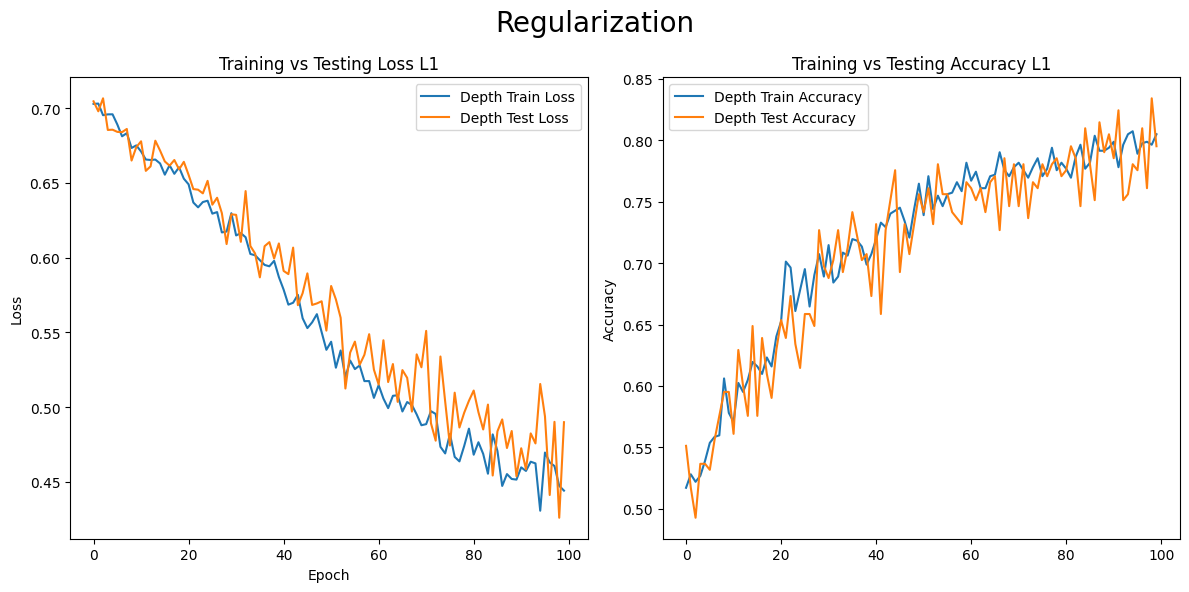

In [14]:
fig, axs = plt.subplots(1,2, figsize=(12,6))

axs[0].plot(history_dropout["train_loss"], label="Depth Train Loss")
axs[0].plot(history_dropout["test_loss"], label="Depth Test Loss")
axs[0].set_title("Training vs Testing Loss L1")
axs[0].set_ylabel("Loss")
axs[0].set_xlabel("Epoch")
axs[0].legend()

axs[1].plot(history_dropout["train_acc"], label="Depth Train Accuracy")
axs[1].plot(history_dropout["test_acc"], label="Depth Test Accuracy")
axs[1].set_title("Training vs Testing Accuracy L1")
axs[1].set_ylabel("Accuracy")
axs[0].set_xlabel("Epoch")
axs[1].legend()

fig.suptitle("Regularization", fontsize=20)
plt.tight_layout()

# History L1

In [15]:
history_L1 = train_with_l1()
history_L1['test_acc'][-1]

tensor(0.5854)

# History L2

In [16]:
history_L2 = train_with_l2()
history_L2['test_acc'][-1]

tensor(0.7171)

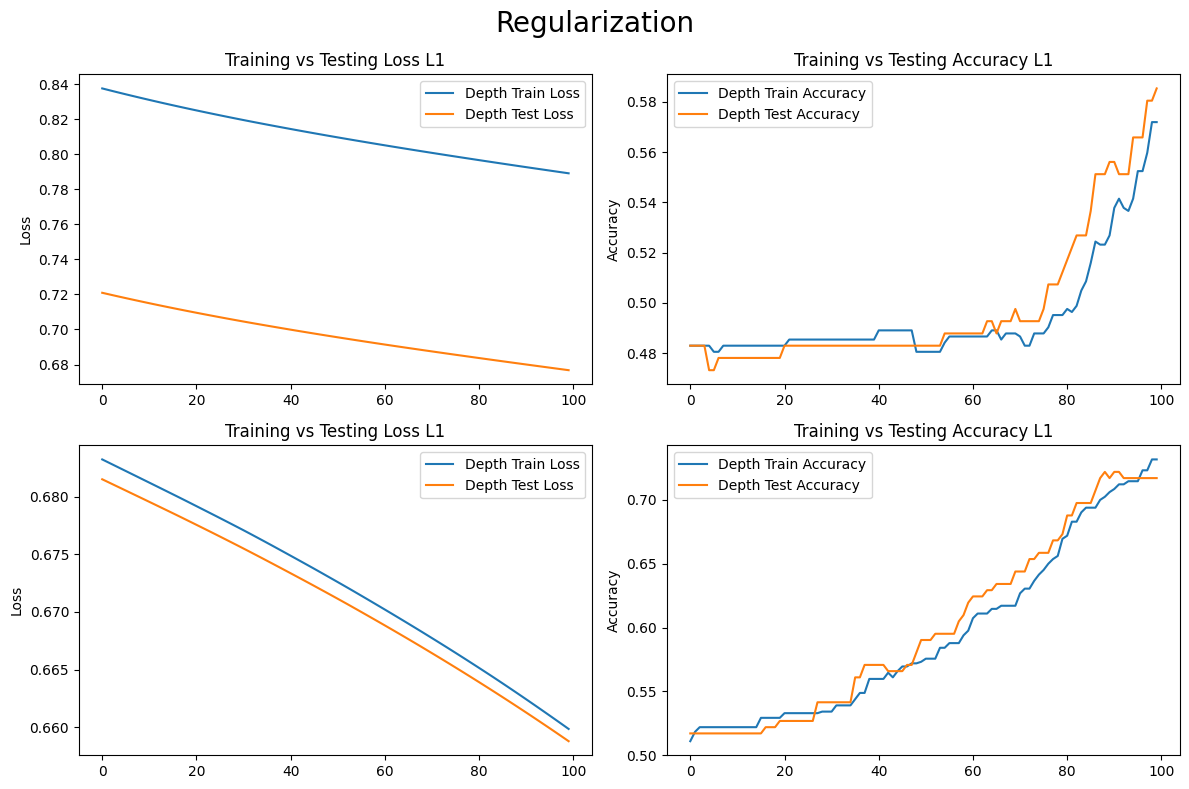

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(12,8))

axs[0,0].plot(history_L1["train_loss"], label="Depth Train Loss")
axs[0,0].plot(history_L1["test_loss"], label="Depth Test Loss")
axs[0,0].set_title("Training vs Testing Loss L1")
axs[0,0].set_ylabel("Loss")
axs[0,0].legend()

axs[0,1].plot(history_L1["train_acc"], label="Depth Train Accuracy")
axs[0,1].plot(history_L1["test_acc"], label="Depth Test Accuracy")
axs[0,1].set_title("Training vs Testing Accuracy L1")
axs[0,1].set_ylabel("Accuracy")
axs[0,1].legend()

axs[1,0].plot(history_L2["train_loss"], label="Depth Train Loss")
axs[1,0].plot(history_L2["test_loss"], label="Depth Test Loss")
axs[1,0].set_title("Training vs Testing Loss L1")
axs[1,0].set_ylabel("Loss")
axs[1,0].legend()

axs[1,1].plot(history_L2["train_acc"], label="Depth Train Accuracy")
axs[1,1].plot(history_L2["test_acc"], label="Depth Test Accuracy")
axs[1,1].set_title("Training vs Testing Accuracy L1")
axs[1,1].set_ylabel("Accuracy")
axs[1,1].legend()

fig.suptitle("Regularization", fontsize=20)
plt.tight_layout()

Seperti di pembahasan Model Depth juga, kita butuh data yang banyak agar model dan visualisasi yang di dapat sangat memuaskan